711 143 843


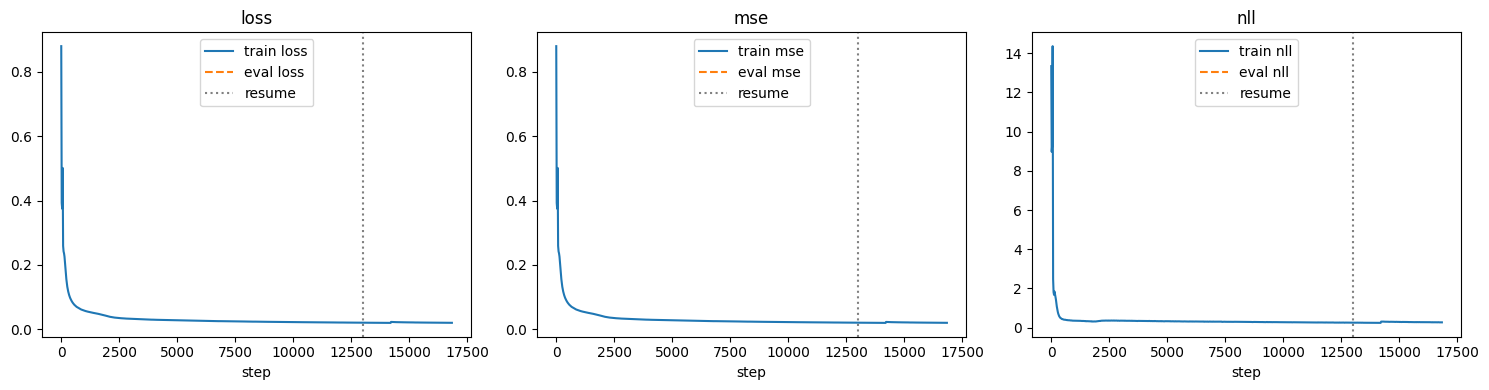

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

df1 = pd.read_csv("diffusion_models/diffuseq_qqp_h128_lr0.0001_t2000_sqrt_lossaware_seed102_test-qqp20260530-16:40:18/progress.csv")
df2 = pd.read_csv("diffusion_models/diffuseq_qqp_h128_lr0.0001_t2000_sqrt_lossaware_seed102_test-qqp-MSEtarget_restart20260608-14:31:07/progress.csv")

df1 = df1.dropna(subset=["step"])
df2 = df2.dropna(subset=["step"])

df = pd.concat([df1, df2]).drop_duplicates(subset="step").sort_values("step").reset_index(drop=True)

print(len(df1), len(df2), len(df))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["loss", "mse", "nll"]):
    ax.plot(df["step"], df[metric], label=f"train {metric}")
    ax.plot(df["step"], df[f"eval_{metric}"], label=f"eval {metric}", linestyle="--")
    ax.axvline(x=13000, color="gray", linestyle=":", label="resume")
    ax.set_xlabel("step")
    ax.set_title(metric)
    ax.legend()

plt.tight_layout()
plt.show()

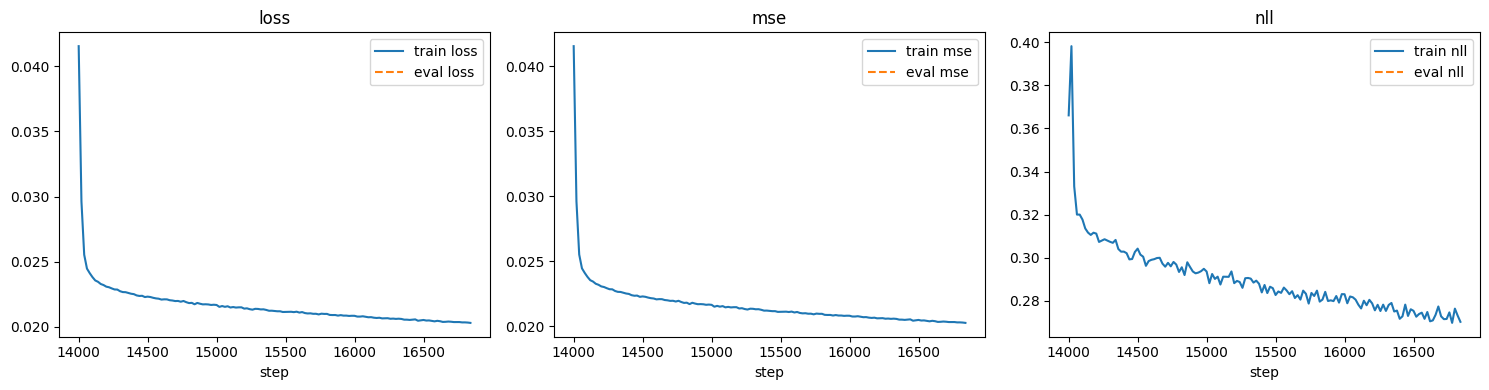

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["loss", "mse", "nll"]):
    ax.plot(df2["step"], df2[metric], label=f"train {metric}")
    ax.plot(df2["step"], df2[f"eval_{metric}"], label=f"eval {metric}", linestyle="--")
    #ax.axvline(x=13000, color="gray", linestyle=":", label="resume")
    ax.set_xlabel("step")
    ax.set_title(metric)
    ax.legend()

plt.tight_layout()
plt.show()